# 21 - DBSCAN Clustering

Implement DBSCAN and identify core, border, and noise points on a 2-feature CSV dataset.

**Problem Statement**

Use DBSCAN to cluster a 2D dataset and label points as core, border, or noise.

**Understanding of Dataset**

We expect a CSV with two numeric columns (`x1`, `x2`). This notebook generates a sample CSV (`dbscan_sample.csv`) and reads it back to simulate exam conditions.

**Theory**

DBSCAN groups points that are closely packed together. Key parameters: `eps` (neighborhood radius) and `min_samples` (minimum points to form a dense region). Points are classified as core (dense center), border (reachable from core but not dense), or noise (outliers).

**Mathematical Representation**

Definitions: For a point p, N_eps(p) = {q | dist(p,q) <= eps}.
- Core: |N_eps(p)| >= min_samples.
- Border: not core, but in N_eps(core_point).
- Noise: not core and not border.

**Pseudocode**

1. Load CSV -> clean missing -> scale features
2. Use DBSCAN(eps, min_samples) to fit -> get labels and core indices
3. Mark core/border/noise and count them
4. Visualize with different markers/colors

In [3]:
# Imports and sample CSV creation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# Create synthetic 2D data with some noise points and save to CSV
X, _ = make_blobs(n_samples=250, centers=[[0,0],[5,5]], cluster_std=0.7, random_state=42)
# add some random noise points far from centers
rng = np.random.RandomState(42)
noise = rng.uniform(low=-6, high=12, size=(30,2))
X_all = np.vstack([X, noise])
df = pd.DataFrame(X_all, columns=['x1','x2'])
df.to_csv('dbscan_sample.csv', index=False)
print('Saved sample CSV: dbscan_sample.csv')

Saved sample CSV: dbscan_sample.csv


In [4]:
# === Load data and quick cleaning ===
data = pd.read_csv('dbscan_sample.csv')
# If needed rename columns to ['x1','x2'] depending on exam CSV
print('Shape before cleaning:', data.shape)
print('Missing values:', data.isnull().sum())
data = data.dropna().reset_index(drop=True)
print('Shape after cleaning:', data.shape)
data.head()

Shape before cleaning: (280, 2)
Missing values: x1    0
x2    0
dtype: int64
Shape after cleaning: (280, 2)


,x1,x2
0,6.180999,5.617148
1,0.758136,0.737661
2,-0.500713,0.475718
3,-0.153770,0.249979
4,5.600362,4.888043


               x1          x2
count  280.000000  280.000000
mean     2.387174    2.603162
std      3.060855    3.017225
min     -5.629479   -5.163893
25%     -0.154434    0.072562
50%      1.560511    3.308722
75%      5.014303    5.010287
max     11.452523   11.458377


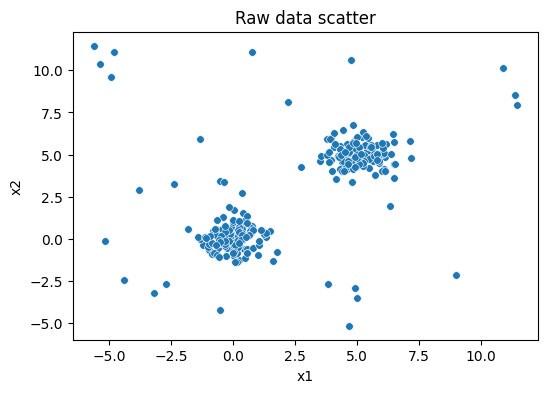

In [5]:
# === Explain data (simple stats) ===
print(data.describe())
plt.figure(figsize=(6,4))
sns.scatterplot(x='x1', y='x2', data=data, s=30)
plt.title('Raw data scatter')
plt.show()

In [6]:
# === Feature scaling (important for distance-based DBSCAN) ===
scaler = StandardScaler()
Xs = scaler.fit_transform(data[['x1','x2']])
Xs = pd.DataFrame(Xs, columns=['x1_s','x2_s'])
Xs.head()

,x1_s,x2_s
0,1.241685,1.000715
1,-0.533170,-0.619390
2,-0.945180,-0.706362
3,-0.831628,-0.781313
4,1.051647,0.758635


In [7]:
# === Fit DBSCAN ===
# Good starting values: eps ~ 0.3-0.6 (in scaled space), min_samples ~ 5
eps = 0.4
min_samples = 5
db = DBSCAN(eps=eps, min_samples=min_samples)
db.fit(Xs)
labels = db.labels_  # -1 means noise
core_indices = db.core_sample_indices_  # indices of core points in the fitted data
core_mask = np.zeros(len(Xs), dtype=bool)
core_mask[core_indices] = True

# Determine point types
point_type = np.array(['']*len(Xs), dtype=object)
point_type[labels == -1] = 'noise'
# core points
point_type[core_mask] = 'core'
# border points: assigned to a cluster but not core
border_mask = (labels != -1) & (~core_mask)
point_type[border_mask] = 'border'

# Counts
unique_labels = set(labels) - {-1} if -1 in set(labels) else set(labels)
n_clusters = len(unique_labels)
n_noise = np.sum(labels == -1)
n_core = np.sum(point_type == 'core')
n_border = np.sum(point_type == 'border')
print('eps=', eps, 'min_samples=', min_samples)
print('Estimated clusters (excluding noise):', n_clusters)
print('Noise points:', n_noise)
print('Core points:', n_core)
print('Border points:', n_border)

# Silhouette score is defined only for >=2 clusters and excludes noise (-1)
labels_for_sil = labels[labels != -1]
Xs_for_sil = Xs.values[labels != -1]
if len(set(labels_for_sil)) >= 2:
    sil = silhouette_score(Xs_for_sil, labels_for_sil)
    print('Silhouette score (non-noise):', sil)
else:
    print('Silhouette score: not enough clusters (need >=2 non-noise clusters)')

eps= 0.4 min_samples= 5
Estimated clusters (excluding noise): 2
Noise points: 24
Core points: 253
Border points: 3
Silhouette score (non-noise): 0.8194723526844236


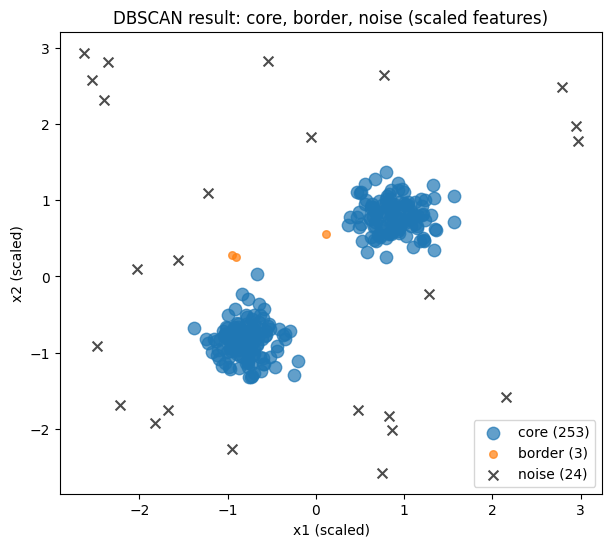

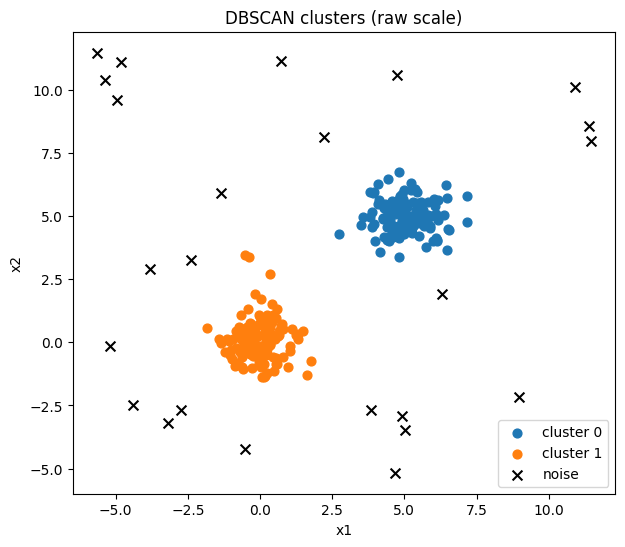

In [8]:
# === Visualization: mark core, border, noise ===
plt.figure(figsize=(7,6))
# core: large circles, border: small circles, noise: x marker
colors = {'core':'C0','border':'C1','noise':'k'}
markers = {'core':'o','border':'o','noise':'x'}
sizes = {'core':80,'border':30,'noise':50}
for t in ['core','border','noise']:
    mask = (point_type == t)
    if np.any(mask):
        plt.scatter(Xs.loc[mask,'x1_s'], Xs.loc[mask,'x2_s'], c=colors[t], marker=markers[t], s=sizes[t], label=f'{t} ({np.sum(mask)})', alpha=0.7)
plt.legend()
plt.title('DBSCAN result: core, border, noise (scaled features)')
plt.xlabel('x1 (scaled)')
plt.ylabel('x2 (scaled)')
plt.show()

# For clarity, also plot clusters in raw scale (non-noise colored)
plt.figure(figsize=(7,6))
raw = data.copy()
raw['label'] = labels
# color by label, noise in black
palette = sns.color_palette('tab10', n_colors=max(1, n_clusters))
for lbl in set(labels):
    if lbl == -1:
        mask = (raw['label'] == -1)
        plt.scatter(raw.loc[mask,'x1'], raw.loc[mask,'x2'], c='k', marker='x', s=50, label='noise')
    else:
        mask = (raw['label'] == lbl)
        plt.scatter(raw.loc[mask,'x1'], raw.loc[mask,'x2'], s=40, label=f'cluster {lbl}')
plt.title('DBSCAN clusters (raw scale)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.show()

In [9]:
# === Save results and summary ===
out = data.copy()
out['label'] = labels
out['point_type'] = point_type
out.to_csv('dbscan_result_with_labels.csv', index=False)
print('Saved dbscan_result_with_labels.csv')
print('Summary: clusters=', n_clusters, 'noise=', n_noise, 'core=', n_core, 'border=', n_border)

Saved dbscan_result_with_labels.csv
Summary: clusters= 2 noise= 24 core= 253 border= 3


**Notes for exam / different CSVs**

- Replace `pd.read_csv('dbscan_sample.csv')` with the provided CSV file.
- Ensure you select two numeric columns (e.g., `data[['col1','col2']]`).
- If clusters are not detected as expected, try tuning `eps` and `min_samples`. Use a k-distance plot (k = min_samples) to choose `eps`.
- DBSCAN is sensitive to feature scaling; keep the scaling step.